# Environmental Change Detection with EfficientNet-Based U-Net

In this notebook, we will develop and evaluate an **EfficientNet-based U-Net** model for environmental change detection using satellite imagery. U-Net is a powerful semantic segmentation architecture that combines an encoder-decoder structure with skip connections to generate detailed pixel-level predictions. In this implementation, the encoder is replaced with a pretrained **EfficientNet** backbone, enabling the model to leverage highly efficient feature representations learned from large-scale image datasets.

EfficientNet introduces a compound scaling strategy that balances network depth, width, and input resolution, allowing it to achieve strong performance while maintaining computational efficiency. By integrating EfficientNet into the U-Net architecture, we combine efficient feature extraction with precise spatial localization, making the model well suited for large-scale Earth observation applications.

Unlike traditional image classification models, which assign a single label to an entire image, semantic segmentation models predict a class for every pixel. This capability is essential for environmental monitoring tasks where it is important not only to detect change but also to determine exactly where it has occurred.

For this task, the model receives satellite images of the same geographic location acquired at two different times: a **Before** image and an **After** image. These images are combined into a multi-channel input and processed by the network to generate a binary change map. Each pixel in the output mask indicates whether a significant environmental change has occurred between the two acquisition dates.

## Environmental Change Detection

In this lab, we will apply an EfficientNet-U-Net model to the problem of environmental monitoring using multi-temporal satellite imagery. The objective is to identify and map regions that have undergone significant change over time.

Specifically, we will focus on detecting changes in infrastructure by analysing paired **Before** and **After** satellite images. The model learns hierarchical spatial features associated with environmental change and produces dense segmentation masks that highlight affected regions.


> **Implementation Note**
>
> The utility functions introduced in previous sections have been refactored into a standalone module named `eff_net_utils.py`. This keeps the notebook concise and improves code reusability.
>
> ```python
> import eff_net_utils as enu
> ```
>
> All subsequent references to data processing, augmentation, model construction, training, and evaluation utilities will use the `enu` prefix.

## Imports

In [1]:
import os
import random
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

import torch.nn as nn
import torch.nn.functional as F

import segmentation_models_pytorch as smp

import eff_net_utils as enu

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Tracking Environmental *Change*

Our goal is to identify significant changes in vegetation by comparing "Before" and "After" images of a location.

We will work with the [LEVIR-CD+](https://www.kaggle.com/datasets/mdrifaturrahman33/levir-cd-change-detection) dataset. 

The dataset has the following structure:
- B = before image
- A = after image
- label = change mask

In [3]:
# Define the path to the root directory containing the dataset.
image1_train_dir = "levir_cd_plus/train/A"       # after
image2_train_dir = "levir_cd_plus/train/B"       # before
mask_train_dir = "levir_cd_plus/train/label"

image1_test_dir = "levir_cd_plus/test/A"         # after
image2_test_dir = "levir_cd_plus/test/B"         # before
mask_test_dir = "levir_cd_plus/test/label"

Check that the path exists

In [4]:
print(os.path.exists(image1_train_dir))
print(os.path.exists(image2_train_dir))
print(os.path.exists(mask_train_dir))

True
True
True


##  Defining transformations


In [5]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = enu.JointTrainTransform(
    size=(224, 224),
    mean=mean,
    std=std
)

test_transform = enu.JointTestTransform(
    size=(224, 224),
    mean=mean,
    std=std
)

In [6]:
train_dataset = enu.ChangeDetectionDataset(
    after_dir=image1_train_dir,
    before_dir=image2_train_dir,
    mask_dir=mask_train_dir,
    transform=train_transform
)

test_dataset = enu.ChangeDetectionDataset(
    after_dir=image1_test_dir,
    before_dir=image2_test_dir,
    mask_dir=mask_test_dir,
    transform=test_transform
)

## Dataloaders

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [8]:
before, after, mask = next(iter(train_loader))

print("Before:", before.shape)
print("After:", after.shape)
print("Mask:", mask.shape)

x = torch.cat([before, after], dim=1)

print("U-Net input:", x.shape)

Before: torch.Size([8, 3, 224, 224])
After: torch.Size([8, 3, 224, 224])
Mask: torch.Size([8, 1, 224, 224])
U-Net input: torch.Size([8, 6, 224, 224])


## The next step is to define a EfficientNet U-Net

We’ll build a fresh U-Net + EfficientNet-B0 encoder and train it with the same BCE + Dice loss.

In [9]:
in_channels=6
out_channels=1

 Let’s visualize a few triplets:

before image | after image | change mask

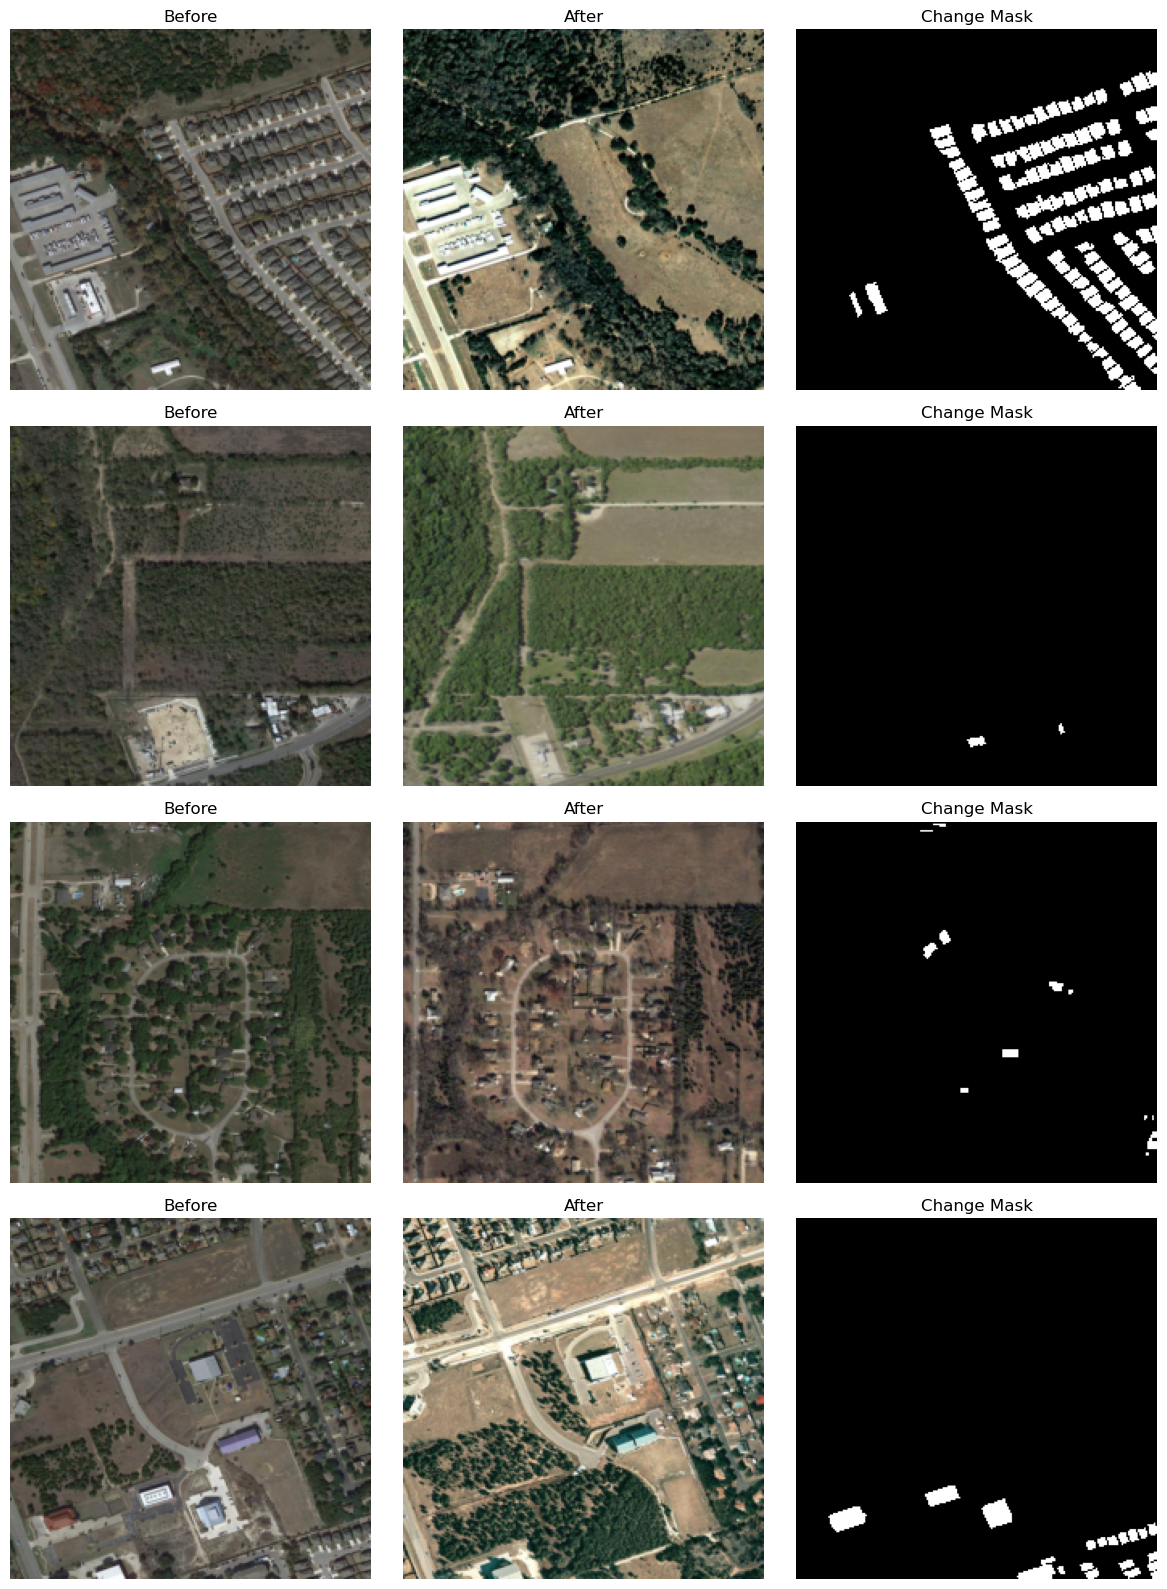

In [10]:
enu.visualize_triplets(test_loader, mean, std, num_samples=4)

## Build a U-Net model for satellite image change detection with a pre-trained encoder.

We will use U-Net +  EfficientNet- encoder. 

in_channels=6  -> before RGB + after RGB
classes=1      -> binary change mask
activation=None -> raw logits for BCE + Dice loss



In [11]:
model_effnet_b0 = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=6,
    classes=1,
    activation=None
).to(device)

Build The Model

In [12]:
before, after, mask = next(iter(train_loader))

before = before.to(device)
after = after.to(device)
mask = mask.to(device)

x = torch.cat([before, after], dim=1)

with torch.no_grad():
    logits = model_effnet_b0(x)

print("Input:", x.shape)
print("Output:", logits.shape)
print("Mask:", mask.shape)

Input: torch.Size([8, 6, 224, 224])
Output: torch.Size([8, 1, 224, 224])
Mask: torch.Size([8, 1, 224, 224])


## Freeze Encoder First

In [13]:
for param in model_effnet_b0.encoder.parameters():
    param.requires_grad = False

In [14]:
optimizer_effnet_b0 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_effnet_b0.parameters()),
    lr=1e-4
)

## Train Decoder For 5 Epochs

In [15]:
criterion_bce_dice = enu.BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

In [18]:
effnet_b0_train_losses = []
effnet_b0_test_losses = []
effnet_b0_test_metrics_history = []

num_epochs = 5

for epoch in range(num_epochs):
    tqdm.write(f"Starting EfficientNet-B0 frozen epoch {epoch + 1}/{num_epochs}")

    train_loss = enu.train_one_epoch(
        model_effnet_b0,
        train_loader,
        criterion_bce_dice,
        optimizer_effnet_b0,
        device
    )

    test_loss, test_metrics = enu.evaluate(
        model_effnet_b0,
        test_loader,
        criterion_bce_dice,
        device
    )

    effnet_b0_train_losses.append(train_loss)
    effnet_b0_test_losses.append(test_loss)
    effnet_b0_test_metrics_history.append(test_metrics)

    tqdm.write(
        f"EffNet-B0 Frozen Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"IoU: {test_metrics['iou']:.4f} "
        f"Dice: {test_metrics['dice']:.4f} "
        f"Precision: {test_metrics['precision']:.4f} "
        f"Recall: {test_metrics['recall']:.4f} "
        f"Accuracy: {test_metrics['accuracy']:.4f}"
    )

Starting EfficientNet-B0 frozen epoch 1/5


EffNet-B0 Frozen Epoch [1/5] Train Loss: 0.5252 Test Loss: 0.5211 IoU: 0.2192 Dice: 0.3538 Precision: 0.2721 Recall: 0.5496 Accuracy: 0.9236
Starting EfficientNet-B0 frozen epoch 2/5


EffNet-B0 Frozen Epoch [2/5] Train Loss: 0.4790 Test Loss: 0.4858 IoU: 0.2389 Dice: 0.3798 Precision: 0.2977 Recall: 0.5632 Accuracy: 0.9295
Starting EfficientNet-B0 frozen epoch 3/5


EffNet-B0 Frozen Epoch [3/5] Train Loss: 0.4381 Test Loss: 0.4669 IoU: 0.2286 Dice: 0.3646 Precision: 0.2895 Recall: 0.5357 Accuracy: 0.9293
Starting EfficientNet-B0 frozen epoch 4/5


EffNet-B0 Frozen Epoch [4/5] Train Loss: 0.4077 Test Loss: 0.4515 IoU: 0.2373 Dice: 0.3760 Precision: 0.2969 Recall: 0.5541 Accuracy: 0.9299
Starting EfficientNet-B0 frozen epoch 5/5


EffNet-B0 Frozen Epoch [5/5] Train Loss: 0.3949 Test Loss: 0.4146 IoU: 0.2669 Dice: 0.4127 Precision: 0.3779 Recall: 0.4832 Accuracy: 0.9479


## Fine-Tune Full Model

In [19]:
for param in model_effnet_b0.encoder.parameters():
    param.requires_grad = True

In [20]:
optimizer_effnet_b0 = torch.optim.Adam(
    model_effnet_b0.parameters(),
    lr=1e-5
)

In [22]:
num_finetune_epochs = 15

for epoch in range(num_finetune_epochs):
    tqdm.write(f"Starting EfficientNet-B0 fine-tune epoch {epoch + 1}/{num_finetune_epochs}")

    train_loss = enu.train_one_epoch(
        model_effnet_b0,
        train_loader,
        criterion_bce_dice,
        optimizer_effnet_b0,
        device
    )

    test_loss, test_metrics = enu.evaluate(
        model_effnet_b0,
        test_loader,
        criterion_bce_dice,
        device
    )

    effnet_b0_train_losses.append(train_loss)
    effnet_b0_test_losses.append(test_loss)
    effnet_b0_test_metrics_history.append(test_metrics)

    tqdm.write(
        f"EffNet-B0 Fine-tune Epoch [{epoch + 1}/{num_finetune_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Test Loss: {test_loss:.4f} "
        f"IoU: {test_metrics['iou']:.4f} "
        f"Dice: {test_metrics['dice']:.4f} "
        f"Precision: {test_metrics['precision']:.4f} "
        f"Recall: {test_metrics['recall']:.4f} "
        f"Accuracy: {test_metrics['accuracy']:.4f}"
    )

Starting EfficientNet-B0 fine-tune epoch 1/15


EffNet-B0 Fine-tune Epoch [1/15] Train Loss: 0.3741 Test Loss: 0.4103 IoU: 0.2733 Dice: 0.4204 Precision: 0.3706 Recall: 0.5154 Accuracy: 0.9463
Starting EfficientNet-B0 fine-tune epoch 2/15


EffNet-B0 Fine-tune Epoch [2/15] Train Loss: 0.3768 Test Loss: 0.4070 IoU: 0.2755 Dice: 0.4226 Precision: 0.3727 Recall: 0.5184 Accuracy: 0.9467
Starting EfficientNet-B0 fine-tune epoch 3/15


EffNet-B0 Fine-tune Epoch [3/15] Train Loss: 0.3725 Test Loss: 0.4047 IoU: 0.2800 Dice: 0.4284 Precision: 0.3670 Recall: 0.5450 Accuracy: 0.9452
Starting EfficientNet-B0 fine-tune epoch 4/15


EffNet-B0 Fine-tune Epoch [4/15] Train Loss: 0.3608 Test Loss: 0.4003 IoU: 0.2822 Dice: 0.4308 Precision: 0.3780 Recall: 0.5297 Accuracy: 0.9472
Starting EfficientNet-B0 fine-tune epoch 5/15


...

EffNet-B0 Fine-tune Epoch [11/15] Train Loss: 0.3400 Test Loss: 0.3811 IoU: 0.2993 Dice: 0.4504 Precision: 0.4031 Recall: 0.5335 Accuracy: 0.9510
Starting EfficientNet-B0 fine-tune epoch 12/15


EffNet-B0 Fine-tune Epoch [12/15] Train Loss: 0.3443 Test Loss: 0.3813 IoU: 0.2997 Dice: 0.4509 Precision: 0.3948 Recall: 0.5495 Accuracy: 0.9495
Starting EfficientNet-B0 fine-tune epoch 13/15


EffNet-B0 Fine-tune Epoch [13/15] Train Loss: 0.3327 Test Loss: 0.3769 IoU: 0.3035 Dice: 0.4556 Precision: 0.4054 Recall: 0.5415 Accuracy: 0.9511
Starting EfficientNet-B0 fine-tune epoch 14/15


EffNet-B0 Fine-tune Epoch [14/15] Train Loss: 0.3380 Test Loss: 0.3753 IoU: 0.3055 Dice: 0.4576 Precision: 0.4038 Recall: 0.5497 Accuracy: 0.9509
Starting EfficientNet-B0 fine-tune epoch 15/15


EffNet-B0 Fine-tune Epoch [15/15] Train Loss: 0.3340 Test Loss: 0.3733 IoU: 0.3071 Dice: 0.4597 Precision: 0.4049 Recall: 0.5529 Accuracy: 0.9509


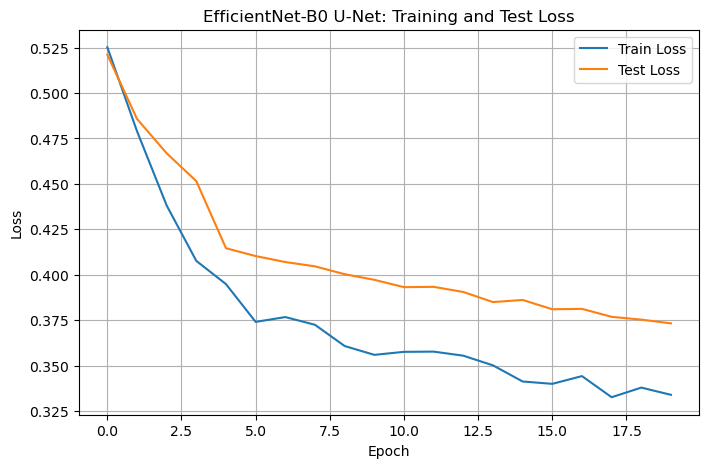

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(effnet_b0_train_losses, label="Train Loss")
plt.plot(effnet_b0_test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 U-Net: Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
ious = [m["iou"] for m in effnet_b0_test_metrics_history]
dices = [m["dice"] for m in effnet_b0_test_metrics_history]
precisions = [m["precision"] for m in effnet_b0_test_metrics_history]
recalls = [m["recall"] for m in effnet_b0_test_metrics_history]
accuracies = [m["accuracy"] for m in effnet_b0_test_metrics_history]

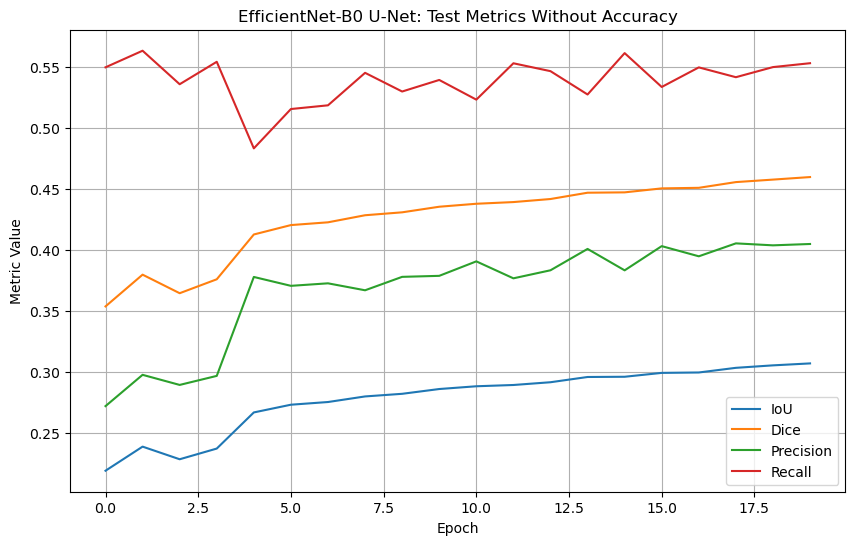

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(ious, label="IoU")
plt.plot(dices, label="Dice")
plt.plot(precisions, label="Precision")
plt.plot(recalls, label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("EfficientNet-B0 U-Net: Test Metrics Without Accuracy")
plt.legend()
plt.grid(True)
plt.show()

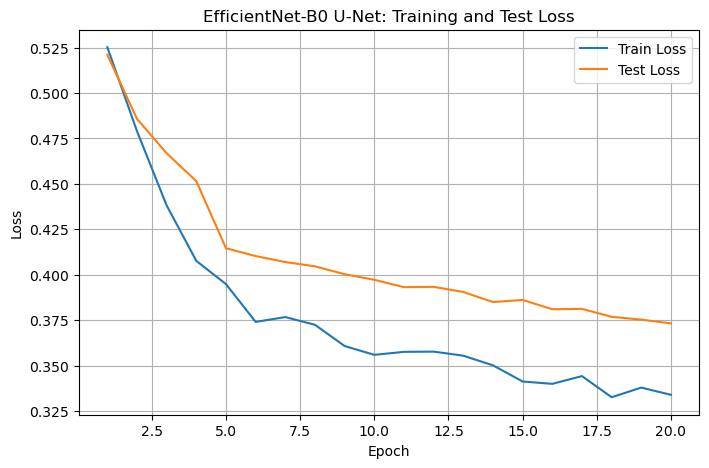

In [27]:
import matplotlib.pyplot as plt

epochs = range(1, len(effnet_b0_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, effnet_b0_train_losses, label="Train Loss")
plt.plot(epochs, effnet_b0_test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 U-Net: Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

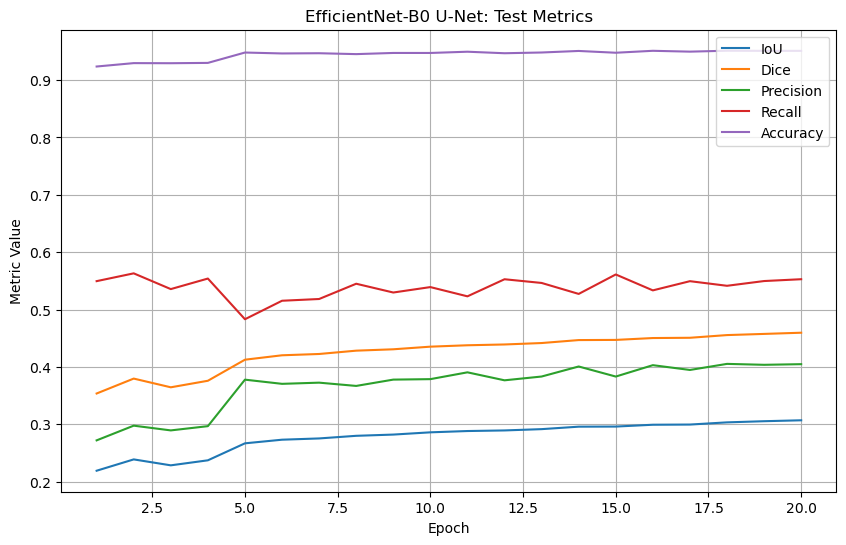

In [28]:
effnet_b0_ious = [m["iou"] for m in effnet_b0_test_metrics_history]
effnet_b0_dices = [m["dice"] for m in effnet_b0_test_metrics_history]
effnet_b0_precisions = [m["precision"] for m in effnet_b0_test_metrics_history]
effnet_b0_recalls = [m["recall"] for m in effnet_b0_test_metrics_history]
effnet_b0_accuracies = [m["accuracy"] for m in effnet_b0_test_metrics_history]

epochs = range(1, len(effnet_b0_test_metrics_history) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, effnet_b0_ious, label="IoU")
plt.plot(epochs, effnet_b0_dices, label="Dice")
plt.plot(epochs, effnet_b0_precisions, label="Precision")
plt.plot(epochs, effnet_b0_recalls, label="Recall")
plt.plot(epochs, effnet_b0_accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("EfficientNet-B0 U-Net: Test Metrics")
plt.legend()
plt.grid(True)
plt.show()

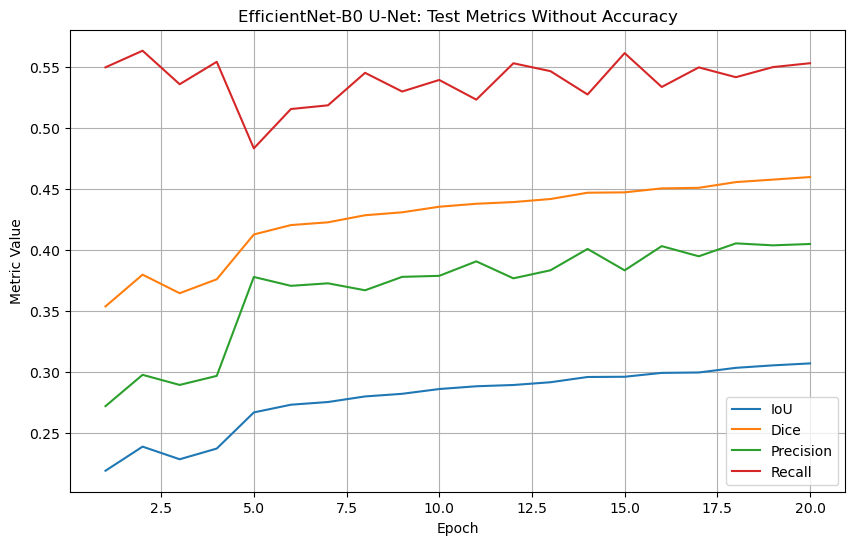

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, effnet_b0_ious, label="IoU")
plt.plot(epochs, effnet_b0_dices, label="Dice")
plt.plot(epochs, effnet_b0_precisions, label="Precision")
plt.plot(epochs, effnet_b0_recalls, label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("EfficientNet-B0 U-Net: Test Metrics Without Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
threshold_results_effnet_b0 = enu.evaluate_at_thresholds(
    model=model_effnet_b0,
    dataloader=test_loader,
    device=device,
    thresholds=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
)

for threshold, metrics in threshold_results_effnet_b0.items():
    print(
        f"Threshold: {threshold:.1f} "
        f"IoU: {metrics['iou']:.4f} "
        f"Dice: {metrics['dice']:.4f} "
        f"Precision: {metrics['precision']:.4f} "
        f"Recall: {metrics['recall']:.4f} "
        f"Accuracy: {metrics['accuracy']:.4f}"
    )

Threshold: 0.1 IoU: 0.2645 Dice: 0.4108 Precision: 0.2897 Recall: 0.7441 Accuracy: 0.9181
Threshold: 0.2 IoU: 0.2897 Dice: 0.4405 Precision: 0.3345 Recall: 0.6752 Accuracy: 0.9346
Threshold: 0.3 IoU: 0.2998 Dice: 0.4520 Precision: 0.3617 Recall: 0.6287 Accuracy: 0.9421
Threshold: 0.4 IoU: 0.3052 Dice: 0.4579 Precision: 0.3842 Recall: 0.5901 Accuracy: 0.9470
Threshold: 0.5 IoU: 0.3071 Dice: 0.4597 Precision: 0.4049 Recall: 0.5529 Accuracy: 0.9509
Threshold: 0.6 IoU: 0.3062 Dice: 0.4583 Precision: 0.4266 Recall: 0.5144 Accuracy: 0.9541
Threshold: 0.7 IoU: 0.3008 Dice: 0.4517 Precision: 0.4524 Recall: 0.4685 Accuracy: 0.9572


In [32]:
def visualize_images_and_predictions(
    model,
    dataloader,
    mean,
    std,
    device,
    num_samples=4,
    threshold=0.5
):
    """
    Visualize before image, after image, true mask, and predicted mask.

    Parameters
    ----------
    model : torch.nn.Module
        Trained segmentation model.
    dataloader : torch.utils.data.DataLoader
        Dataloader returning before, after, and mask tensors.
    mean : list
        Channel-wise mean used during normalization.
    std : list
        Channel-wise standard deviation used during normalization.
    device : torch.device
        Device used for inference.
    num_samples : int
        Number of samples to visualize.
    threshold : float
        Probability threshold used to convert predictions to binary masks.
    """
    model.eval()

    before_batch, after_batch, mask_batch = next(iter(dataloader))

    before_batch = before_batch.to(device)
    after_batch = after_batch.to(device)
    mask_batch = mask_batch.to(device)

    x = torch.cat([before_batch, after_batch], dim=1)

    with torch.no_grad():
        logits = model(x)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities > threshold).float()

    before_batch = before_batch.cpu()
    after_batch = after_batch.cpu()
    mask_batch = mask_batch.cpu()
    predictions = predictions.cpu()

    num_samples = min(num_samples, before_batch.size(0))

    fig, axes = plt.subplots(
        num_samples,
        4,
        figsize=(16, 4 * num_samples)
    )

    if num_samples == 1:
        axes = axes.reshape(1, 4)

    for i in range(num_samples):
        before = enu.denormalize_image(before_batch[i], mean, std)
        after = enu.denormalize_image(after_batch[i], mean, std)
        true_mask = mask_batch[i].squeeze(0)
        pred_mask = predictions[i].squeeze(0)

        before = before.permute(1, 2, 0).numpy()
        after = after.permute(1, 2, 0).numpy()
        true_mask = true_mask.numpy()
        pred_mask = pred_mask.numpy()

        axes[i, 0].imshow(before)
        axes[i, 0].set_title("Before")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(after)
        axes[i, 1].set_title("After")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(true_mask, cmap="gray")
        axes[i, 2].set_title("True Mask")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred_mask, cmap="gray")
        axes[i, 3].set_title("Predicted Mask")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'denormalize_image' is not defined

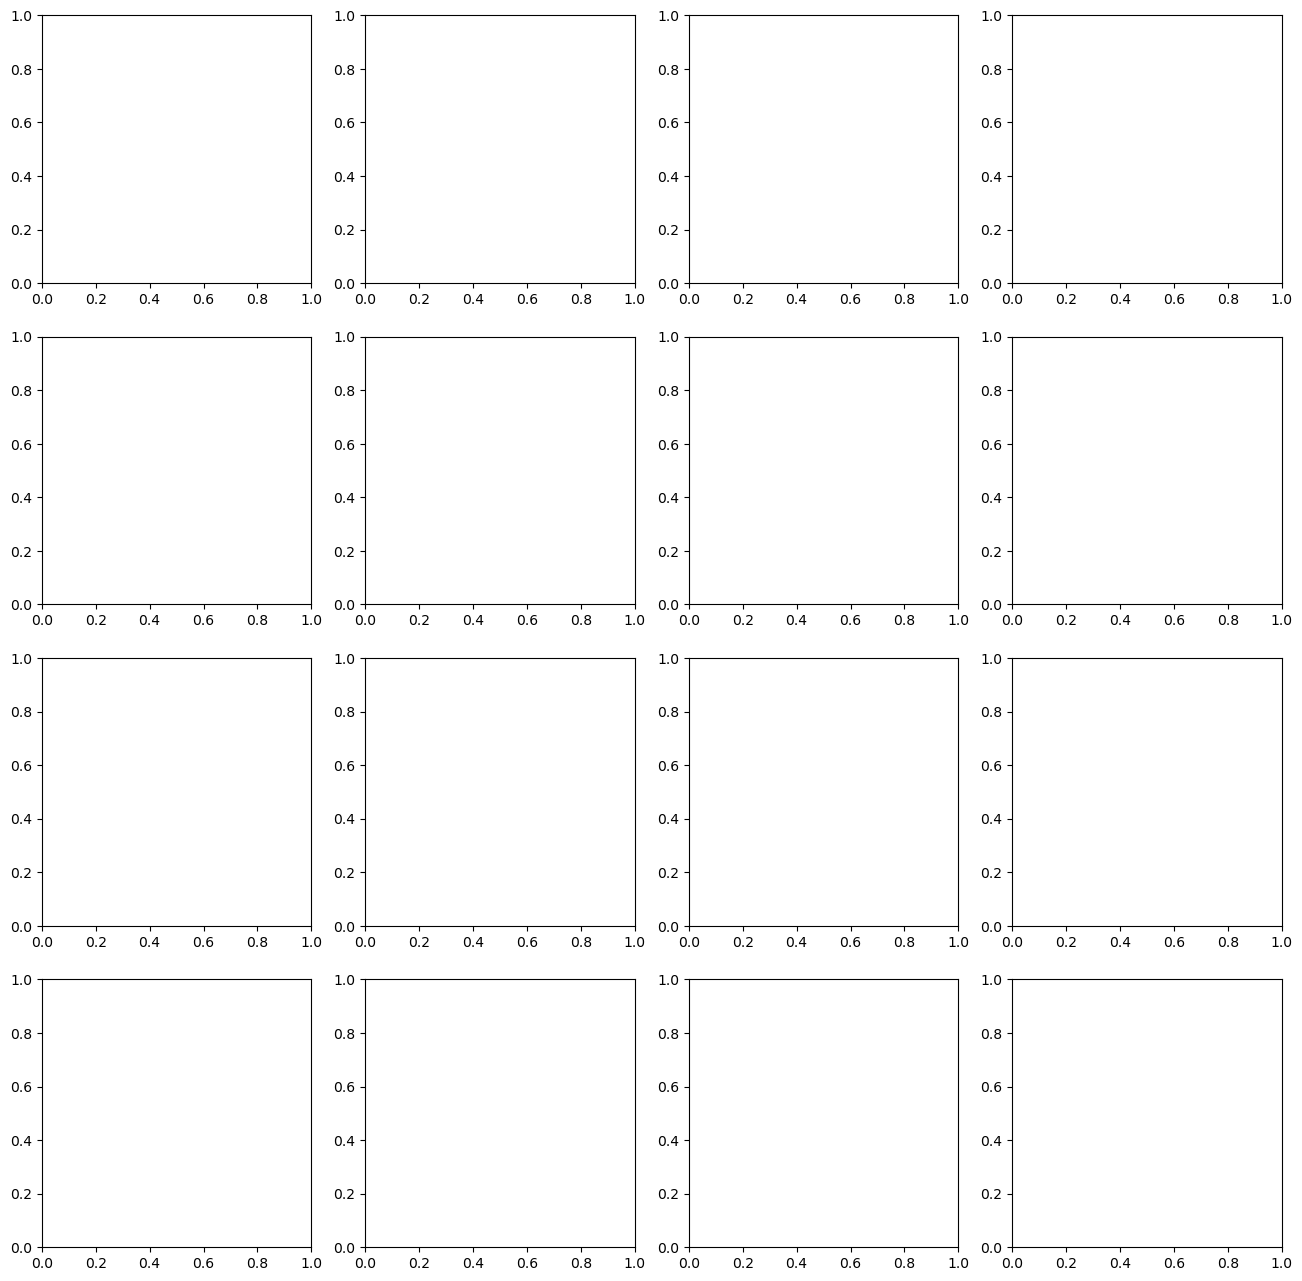

In [33]:
visualize_images_and_predictions(
    model=model_effnet_b0,
    dataloader=test_loader,
    mean=mean,
    std=std,
    device=device,
    num_samples=4,
    threshold=0.5
)